# EDA: feature by feature

For every feature, three questions:
1. **How many values are missing?** Is the fraud rate different when the value is missing?
2. **Which values or groups have more frauds?** (blue = purchases, pink = % of frauds, dashed line = average)
3. **In one sentence: is this feature useful?** → the *Finding* under each chart.

How strong is a feature: riskiest group ÷ average fraud rate. **Under 1.5 weak, over 2 interesting, over 3 strong.**

Types of feature:
- **numbers** (the double makes sense: amount, days, counts) → `numeric(train, col)`: 10 groups with the same number of purchases
- **codes / categories** (a label, like a postal code: card, addr, email, M) → `category(train, col)`: most frequent values
- **many similar columns** (C, D, V) → `overview(train, cols)` (one row per column) and `copies(train, cols)` (which columns are almost copies)

Only months 0–3: the last months are kept hidden for the final test of the model.

## Functions

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BLUE = "#A7C7E7"     # pastel blue: purchases
PINK = "#F4A7B9"     # pastel pink: frauds
LINE = "#6B6B6B"     # dark grey: average line
IMAGES = Path("../docs/images")   # charts saved here are shown in the README


def missing(df, col):
    """Question 1: how many values are missing, and the fraud rate with / without a value."""
    m = df[col].isna()
    print(f"{col}: missing {100 * m.mean():.1f}% of the rows")
    if 0 < m.sum() < len(df):
        print(f"  fraud rate WITH a value:    {100 * df.loc[~m, 'isFraud'].mean():.2f}%")
        print(f"  fraud rate WITHOUT a value: {100 * df.loc[m, 'isFraud'].mean():.2f}%")


def _plot(groups, overall_pct, title, save=None):
    """groups must have 'purchases' and 'fraud_pct' (already in %). save = file name in docs/images/."""
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    x = range(len(groups))
    top.bar(x, groups["purchases"], color=BLUE)
    top.set_ylabel("purchases")
    top.set_title(title)
    bottom.bar(x, groups["fraud_pct"], color=PINK)
    bottom.axhline(overall_pct, color=LINE, linestyle="--", label=f"average {overall_pct:.1f}%")
    bottom.set_ylabel("frauds (%)")
    bottom.legend(frameon=False)
    bottom.set_xticks(list(x), list(groups.index), rotation=45, ha="right")
    for ax in (top, bottom):
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    if save:
        IMAGES.mkdir(parents=True, exist_ok=True)
        plt.savefig(IMAGES / save, dpi=120)
    plt.show()


def _summary(df, labels):
    """Purchases and % of frauds for each group."""
    groups = df.groupby(labels)["isFraud"].agg(purchases="size", fraud_pct="mean")
    groups["fraud_pct"] = groups["fraud_pct"] * 100          # to % (ONLY here)
    return groups


def numeric(df, col, n_groups=10, save=None):
    """Numbers: 10 groups with the same number of purchases, from the lowest to the highest values."""
    missing(df, col)
    g = pd.qcut(df[col], n_groups, duplicates="drop")
    names = {c: f"{c.left:,.0f}–{c.right:,.0f}" for c in g.cat.categories}
    labels = g.map(names).astype(str).where(df[col].notna(), "missing")
    groups = _summary(df, labels)
    order = list(names.values()) + ["missing"]
    groups = groups.reindex([o for o in order if o in groups.index])
    _plot(groups, df["isFraud"].mean() * 100, f"{col}: purchases and frauds per group", save)
    return groups


def category(df, col, top=15, save=None):
    """Codes: the `top` most frequent values, the others in "other", empty values in "missing"."""
    missing(df, col)
    v = df[col].astype("object")
    frequent = v.value_counts().head(top).index
    labels = v.where(v.isin(frequent), "other").where(v.notna(), "missing").astype(str)
    groups = _summary(df, labels).sort_values("purchases", ascending=False)
    _plot(groups, df["isFraud"].mean() * 100, f"{col}: purchases and frauds per value", save)
    return groups


def by_time(df, col, title, save=None):
    """Time columns (month, hour, weekday): one bar per value, in order."""
    groups = _summary(df, df[col]).sort_index()
    _plot(groups, df["isFraud"].mean() * 100, title, save)
    return groups


def overview(df, cols):
    """One row per column: missing values, fraud when missing, weakest and strongest group, strength."""
    avg = df["isFraud"].mean()
    rows = []
    for c in cols:
        values, m = df[c], df[c].isna()
        groups = pd.qcut(values, 10, duplicates="drop")
        rates = df.groupby(groups, observed=True)["isFraud"].mean()
        rows.append({
            "column": c,
            "missing %": round(100 * m.mean(), 1),
            "fraud % if missing": round(100 * df.loc[m, "isFraud"].mean(), 1) if m.any() else None,
            "lowest group %": round(100 * rates.min(), 1),
            "highest group %": round(100 * rates.max(), 1),
            "strength": round(rates.max() / avg, 1),       # highest group / average
        })
    return pd.DataFrame(rows).set_index("column")


def copies(df, cols, limit=0.95):
    """Heatmap of the correlation between columns; prints the pairs that are almost copies (>= limit)."""
    corr = df[cols].corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr, cmap="PuBu", vmin=0, vmax=1)          # white = unrelated, blue = copies
    ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols)), cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title("How much the columns move together (1 = copies)")
    plt.tight_layout()
    plt.show()
    pairs = [(a, b, round(float(corr.loc[a, b]), 2)) for i, a in enumerate(cols) for b in cols[i + 1:]
             if corr.loc[a, b] >= limit]
    print("almost copies:", pairs if pairs else "none")


def keep_one(df, cols, limit=0.95):
    """Groups of copies: columns linked by a chain of correlations >= limit (if A~B and B~C, then A, B, C
    are one group). From each group keep ONE column: the one with fewer missing values; if equal, the one
    with higher strength. Returns the list of kept columns."""
    corr = df[cols].corr().abs()
    parent = {c: c for c in cols}
    def root(c):
        while parent[c] != c:
            c = parent[c]
        return c
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            if corr.loc[a, b] >= limit:
                parent[root(b)] = root(a)
    groups = {}
    for c in cols:
        groups.setdefault(root(c), []).append(c)
    table = overview(df, cols)
    kept = []
    for members in groups.values():
        best = min(members, key=lambda c: (table.loc[c, "missing %"], -table.loc[c, "strength"]))
        kept.append(best)
        if len(members) > 1:
            print(f"copies {members} -> keep {best}")
    print(f"{len(cols)} columns -> {len(kept)} kept: {kept}")
    return kept

## Data

In [4]:
DATA_FILE = "../data/raw/train_transaction.csv"   # if it is not found, write the full path here

df = pd.read_csv(DATA_FILE)

DAY, HOUR = 86400, 3600                         # TransactionDT is in seconds from a hidden start
df["day"] = df["TransactionDT"] // DAY
df["month"] = df["day"] // 30
df.loc[df["month"] == 6, "month"] = 5          # "month 6" = last 2 days, joined to month 5
df["hour"] = (df["TransactionDT"] // HOUR) % 24
df["weekday"] = df["day"] % 7
df = df.copy()

print("all data:", df.shape, f"fraud rate {df['isFraud'].mean() * 100:.2f}%")
train = df[df["month"] <= 3].copy()           # EDA only on months 0-3
print("months 0-3:", train.shape, f"fraud rate {train['isFraud'].mean() * 100:.2f}%")

/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_22286/2426063645.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day"] = df["TransactionDT"] // DAY
/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_22286/2426063645.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["month"] = df["day"] // 30
/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_22286/2426063645.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

all data: (590540, 398) fraud rate 3.50%
months 0-3: (410601, 398) fraud rate 3.51%


## 0. Time

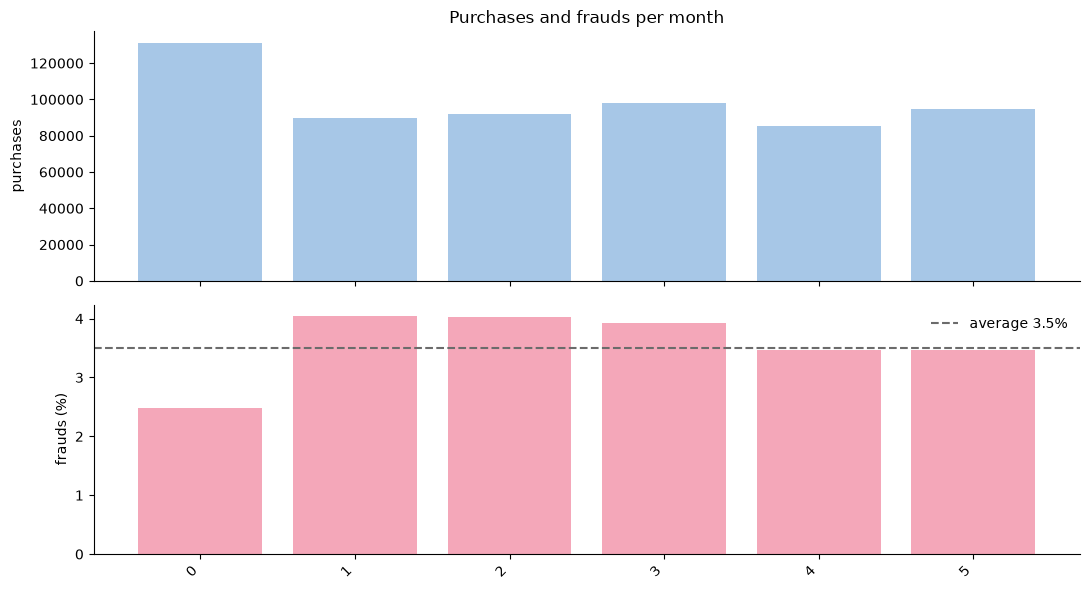

,purchases,fraud_pct
month,,
0,130968,2.476177
1,89838,4.037267
2,91768,4.031907
3,98027,3.926469
4,85303,3.472328
5,94636,3.468025


In [5]:
by_time(df, "month", "Purchases and frauds per month", save="per_month.png")   # all months: only to see if fraud changes over time

**Finding:** The fraud rate changes over time: 2.5% in month 0 (probably the Christmas period, many honest purchases), then 3.4–4%. The model must be trained on the past and tested on the future, never on a random split.

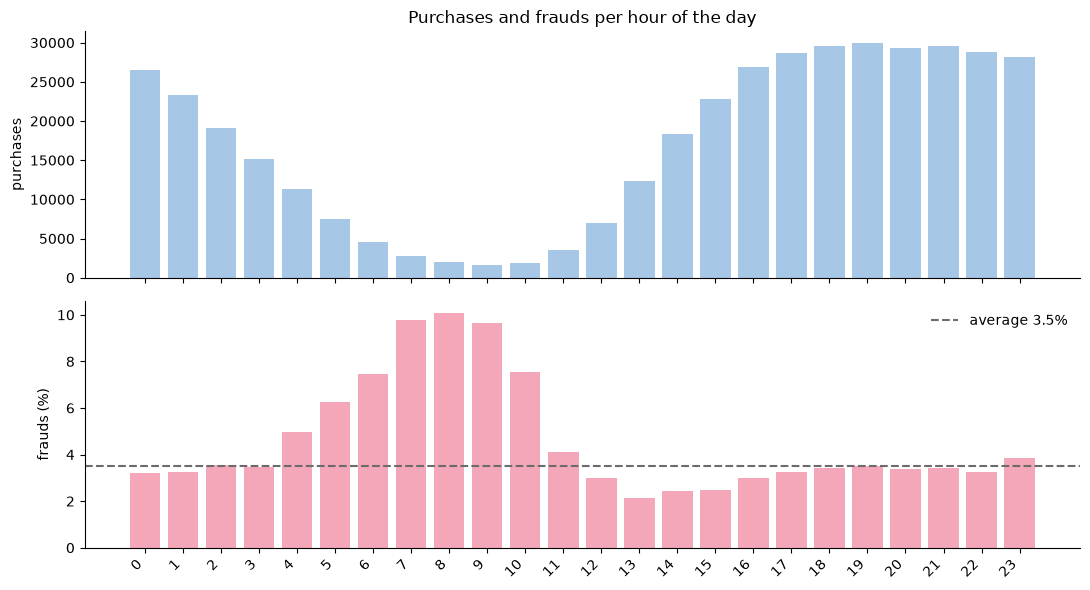

,purchases,fraud_pct
hour,,
0,26564,3.214877
1,23369,3.256451
2,19150,3.571802
3,15208,3.471857
4,11280,4.991135
5,7541,6.272378
6,4578,7.470511
7,2821,9.783765
8,1945,10.077121


In [6]:
by_time(train, "hour", "Purchases and frauds per hour of the day", save="per_hour.png")

**Finding:** Strong. Between hours 5 and 10 (the night: very few purchases) the fraud rate goes up to 10.6%, 3x the average. Most frauds still happen during the day, when there are many more purchases.

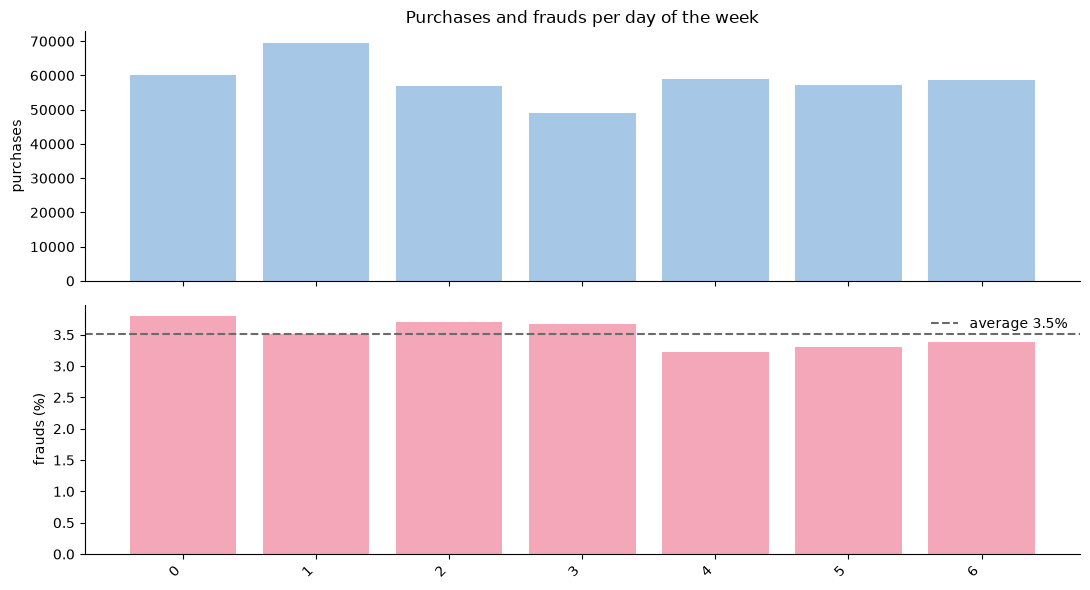

,purchases,fraud_pct
weekday,,
0,60270,3.792932
1,69421,3.516227
2,56973,3.710530
3,48937,3.665938
4,59080,3.224441
5,57121,3.303514
6,58799,3.387813


In [7]:
by_time(train, "weekday", "Purchases and frauds per day of the week", save="per_weekday.png")

**Finding:** _write here._

## 1. TransactionAmt (amount)

Type: **number**

TransactionAmt: missing 0.0% of the rows


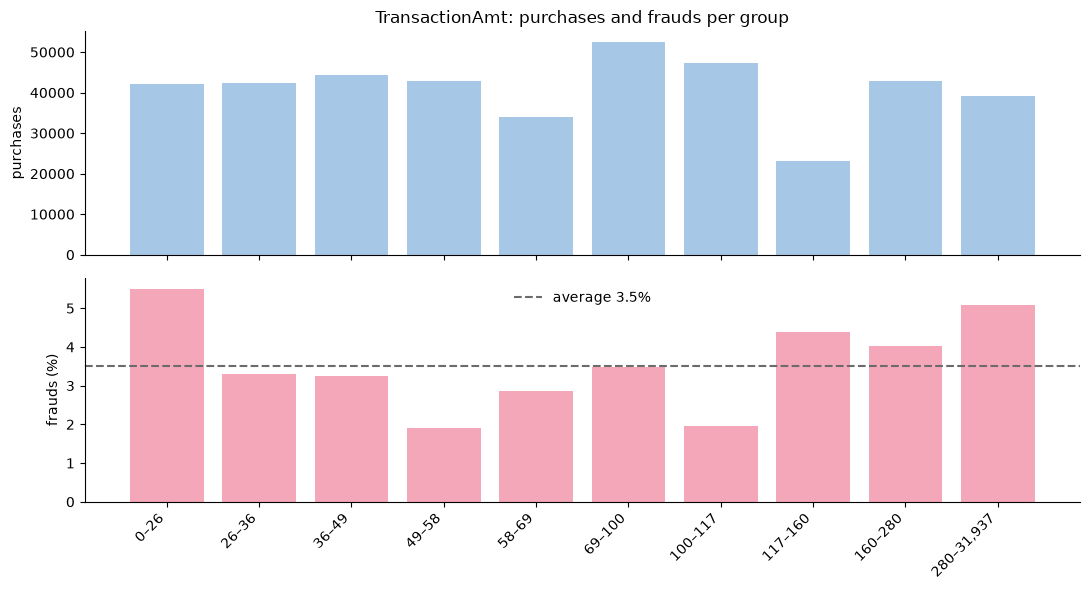

,purchases,fraud_pct
TransactionAmt,,
0–26,42164,5.497581
26–36,42309,3.292444
36–49,44386,3.242013
49–58,42766,1.905719
58–69,33923,2.865313
69–100,52500,3.472381
100–117,47277,1.954439
117–160,23180,4.378775
160–280,42948,4.023470


In [8]:
numeric(train, "TransactionAmt")

**Finding:** Weak alone: the fraud rate goes from 2% to 5.5% (average 3.5%). U-shape: more fraud for very small amounts (possibly thieves testing the card) and very large amounts. More useful compared to the card's usual amount → new feature: amount / average amount of the card.

## 2. ProductCD (type of product)

Type: **code, few values**

ProductCD: missing 0.0% of the rows


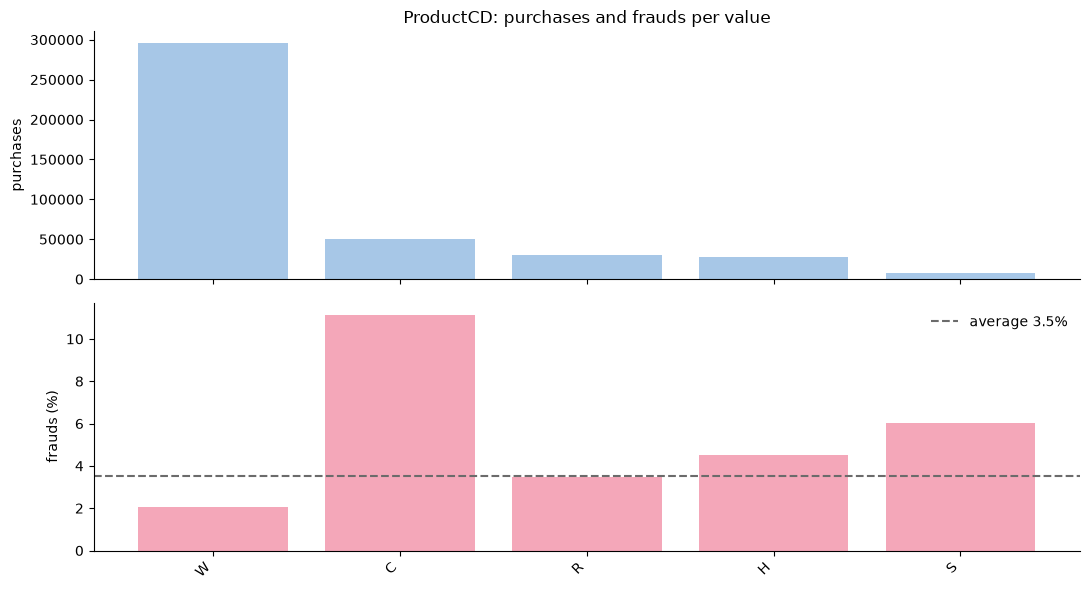

,purchases,fraud_pct
ProductCD,,
W,295680,2.074878
C,49665,11.150710
R,30037,3.475713
H,28048,4.524387
S,7171,6.038209


In [9]:
category(train, "ProductCD")

**Finding:** Strong. Type C has 11% fraud (3x the average) on ~50,000 purchases: almost as many frauds as type W, which has 6x more purchases. W, the most common type, is the safest (2%).

## 3. card1 – card6 (the card)

Type: **codes**. card4 and card6 have few values, card1/2/3/5 many.

card4: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 3.14%


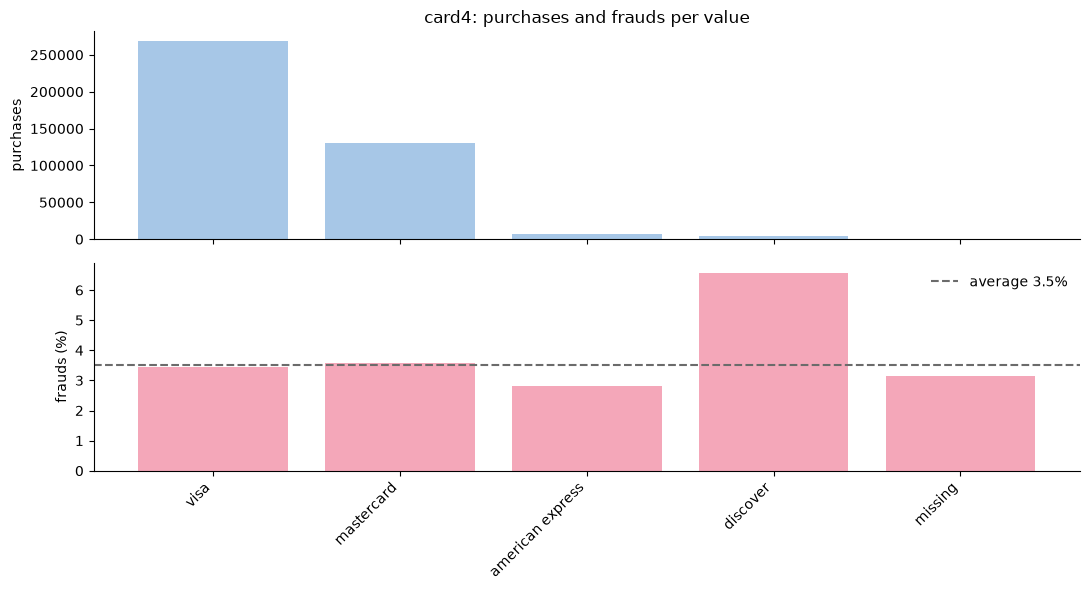

,purchases,fraud_pct
card4,,
visa,268406,3.449997
mastercard,129895,3.565957
american express,6726,2.809991
discover,4745,6.575342
missing,829,3.136309


In [10]:
category(train, "card4")

**Finding:** Weak. Visa and Mastercard are at the average; American Express is below it (2.8%). Only Discover is riskier (6.6%), on a few thousand purchases. Missing values: below the average.

card6: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 2.91%


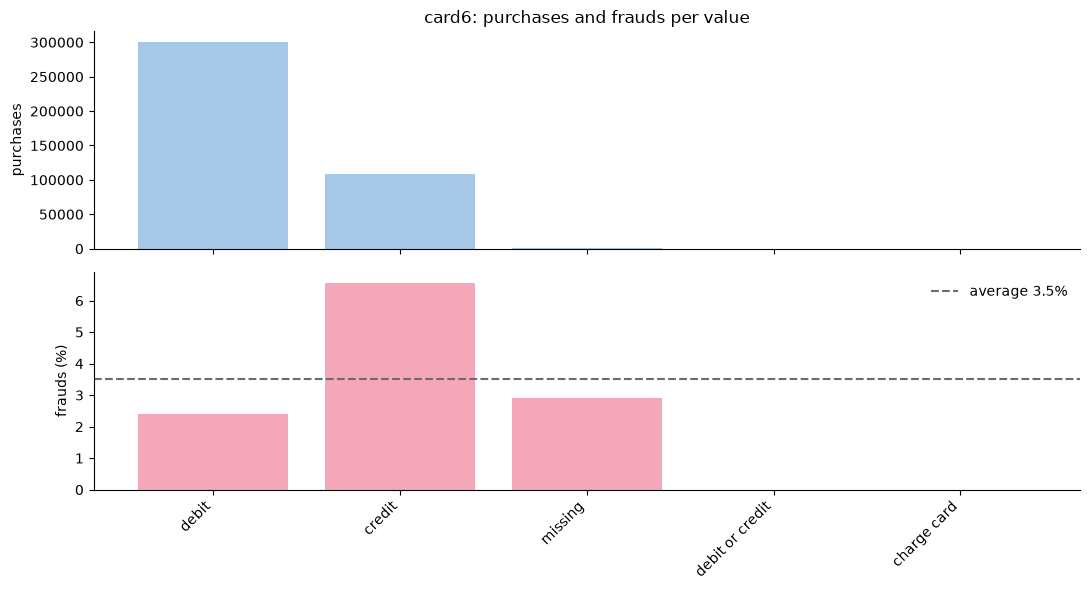

,purchases,fraud_pct
card6,,
debit,300865,2.407392
credit,108866,6.569544
missing,826,2.905569
debit or credit,29,0.000000
charge card,15,0.000000


In [11]:
category(train, "card6")

**Finding:** Useful. Credit cards have almost 3x the fraud rate of debit cards (6.6% vs 2.4%), on ~110,000 purchases.

card1: missing 0.0% of the rows


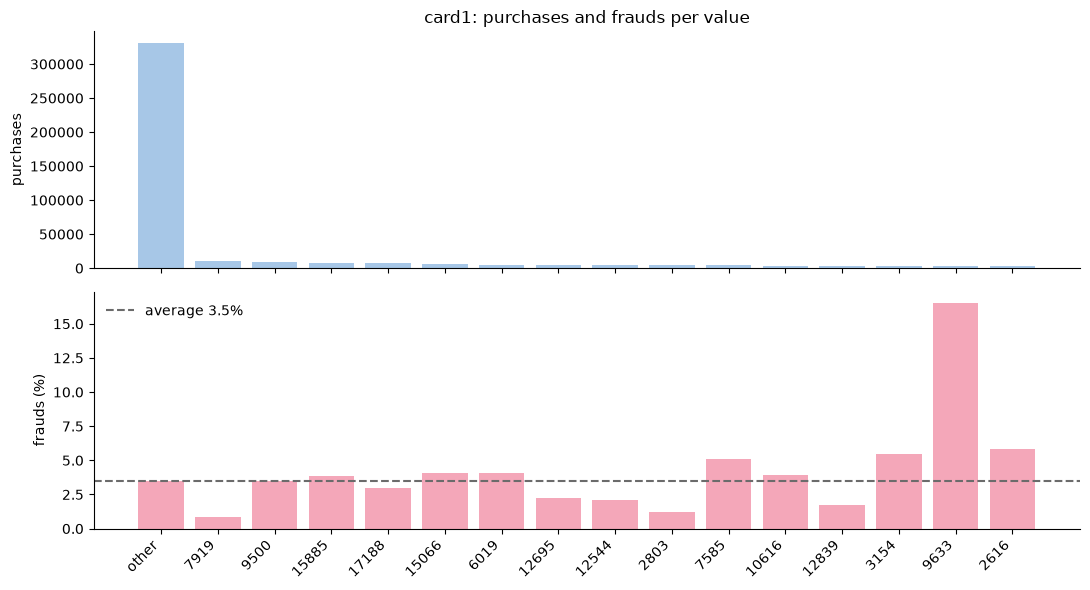

,purchases,fraud_pct
card1,,
other,331509,3.477432
7919,9878,0.860498
9500,9614,3.453297
15885,7487,3.833311
17188,7060,2.988669
15066,5439,4.063247
6019,5169,4.043335
12695,4741,2.214723
12544,4601,2.064769


In [12]:
category(train, "card1")

**Finding:** Too many values (thousands) to use as a category: each code is a small group of cards. Some codes are very risky (9633: 16.5% on ~3,000 purchases). Main use: one of the pieces to identify the same card / customer.

card2: missing 1.6% of the rows
  fraud rate WITH a value:    3.47%
  fraud rate WITHOUT a value: 5.89%


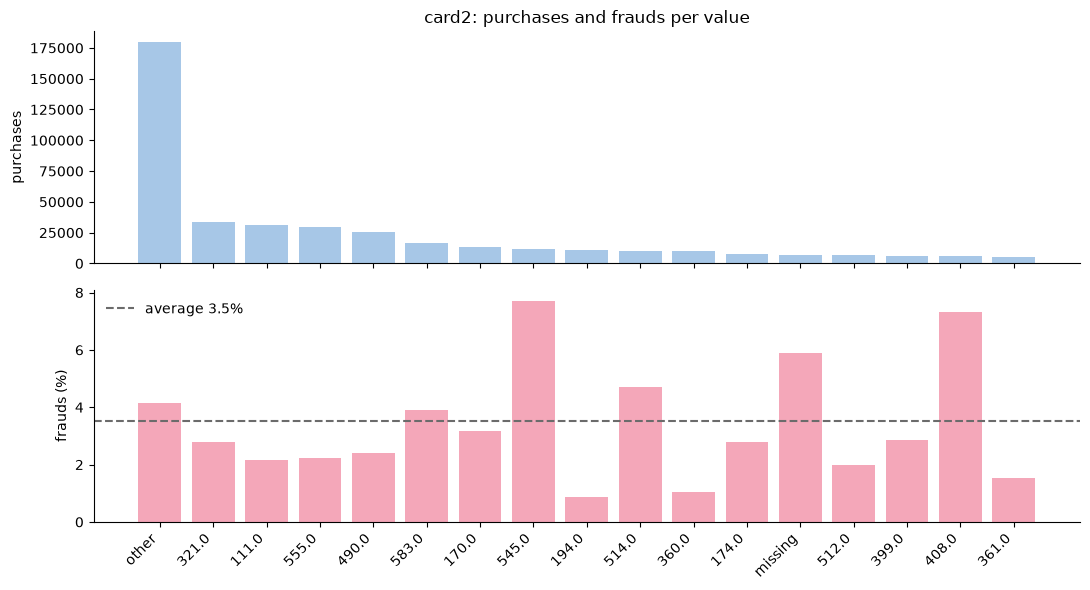

,purchases,fraud_pct
card2,,
other,179492,4.157845
321.0,33427,2.773207
111.0,31255,2.159654
555.0,29474,2.242655
490.0,25853,2.394306
583.0,16395,3.903629
170.0,13014,3.188874
545.0,11816,7.709885
194.0,11270,0.887311


In [13]:
category(train, "card2")

**Finding:** Useful but weaker. A few codes are about 2x the average (545, 408: ~7.5%). When missing, fraud is 5.9%.

card3: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 2.92%


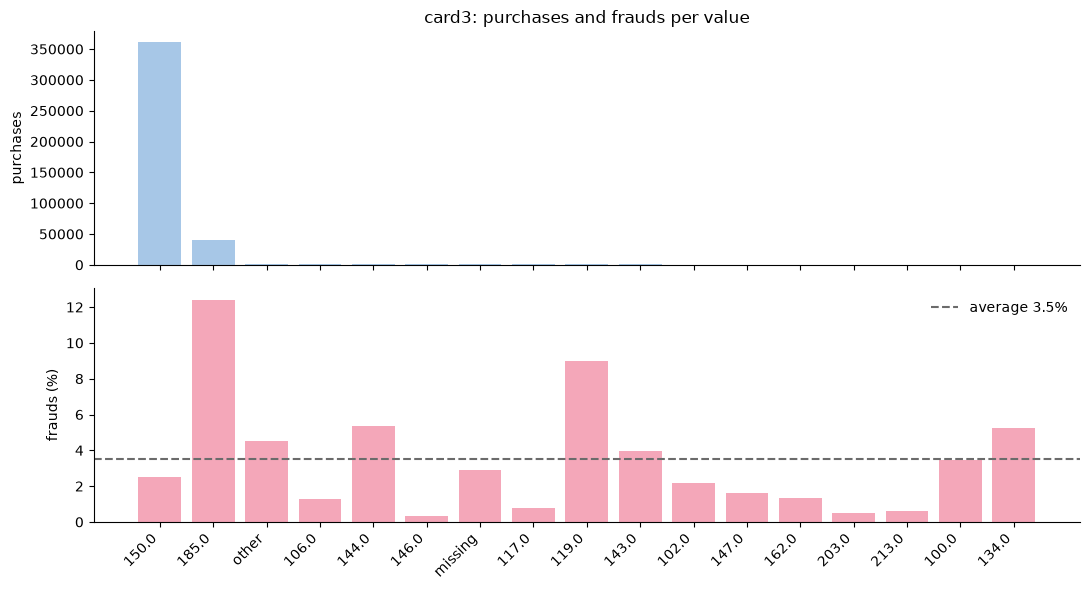

,purchases,fraud_pct
card3,,
150.0,360717,2.507783
185.0,40913,12.419036
other,1863,4.508857
106.0,1111,1.260126
144.0,986,5.375254
146.0,889,0.337458
missing,821,2.923264
117.0,646,0.773994
119.0,644,9.006211


In [14]:
category(train, "card3")

**Finding:** Strong. One value (150, probably the home country) covers most purchases and is below the average (2.5%). Value 185 (probably foreign cards) has 12.4% fraud on ~40,000 purchases (3.5x the average).

card5: missing 0.7% of the rows
  fraud rate WITH a value:    3.50%
  fraud rate WITHOUT a value: 5.03%


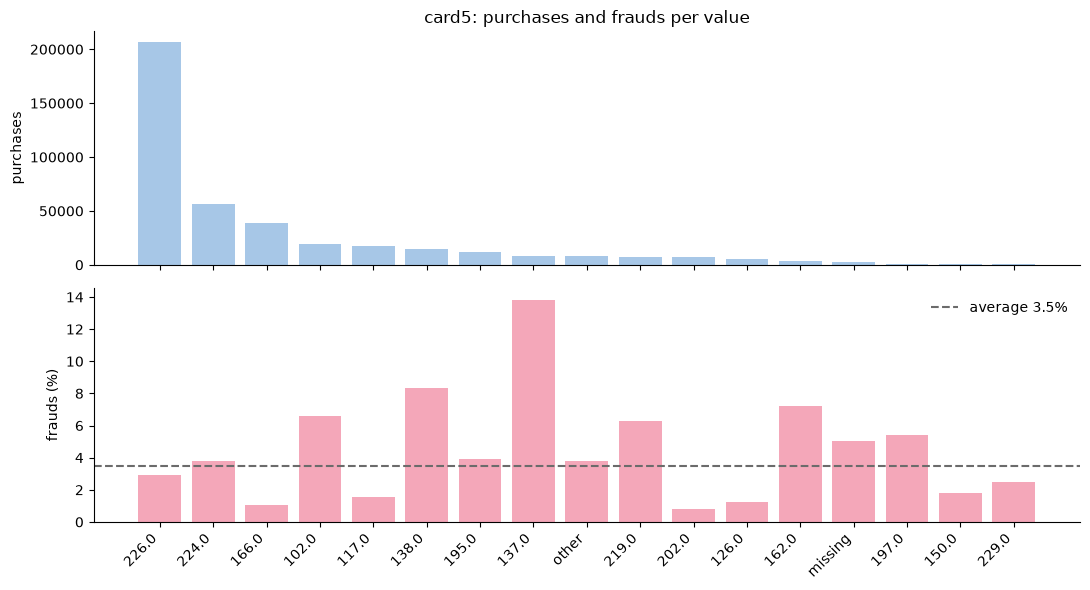

,purchases,fraud_pct
card5,,
226.0,206320,2.945909
224.0,56297,3.811926
166.0,38726,1.025151
102.0,19691,6.607079
117.0,17337,1.563131
138.0,14344,8.317066
195.0,11880,3.922559
137.0,8497,13.840179
other,8310,3.790614


In [15]:
category(train, "card5")

**Finding:** Useful. Some card groups (bank or category) are much riskier: 137 has 14% fraud on ~8,000 purchases, 138 has 8%. The largest group (226) is at the average.

## 4. Address and distance

`addr1`, `addr2`: codes (billing region and country) · `dist1`, `dist2`: numbers

addr1: missing 11.5% of the rows
  fraud rate WITH a value:    2.51%
  fraud rate WITHOUT a value: 11.22%


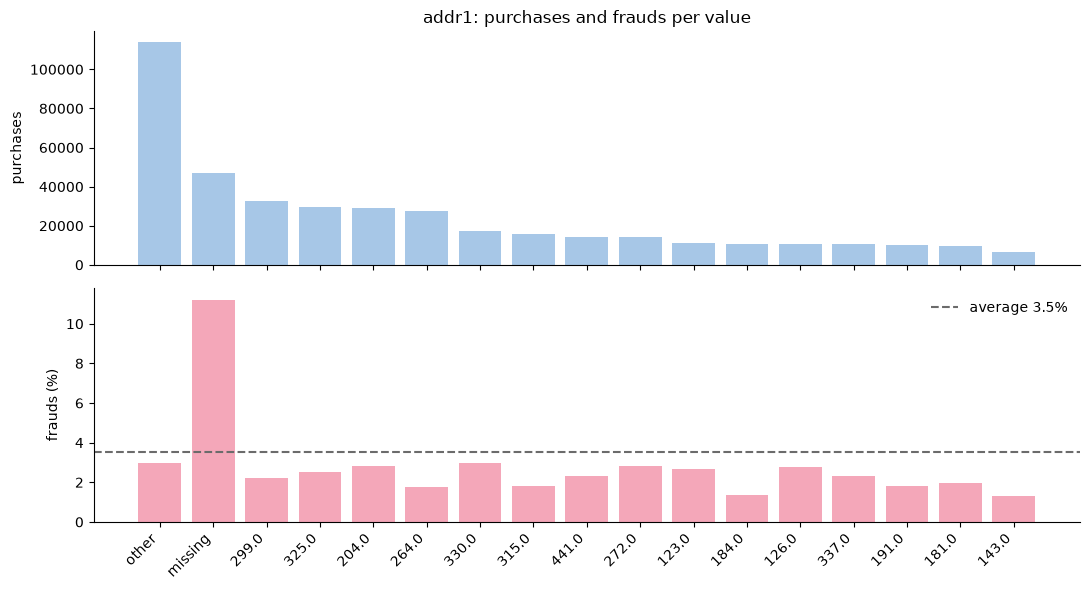

,purchases,fraud_pct
addr1,,
other,113761,2.972020
missing,47184,11.219905
299.0,32713,2.204017
325.0,29495,2.502119
204.0,28984,2.836047
264.0,27507,1.788636
330.0,17228,2.977711
315.0,15842,1.817952
441.0,14312,2.312745


In [16]:
category(train, "addr1")

**Finding:** The value itself says little (all regions are around or below the average). What matters is when it is missing: 11% fraud on ~47,000 purchases (3x the average). No billing address = no address check = easier for a thief → new feature: addr1 missing yes/no.

addr2: missing 11.5% of the rows
  fraud rate WITH a value:    2.51%
  fraud rate WITHOUT a value: 11.22%


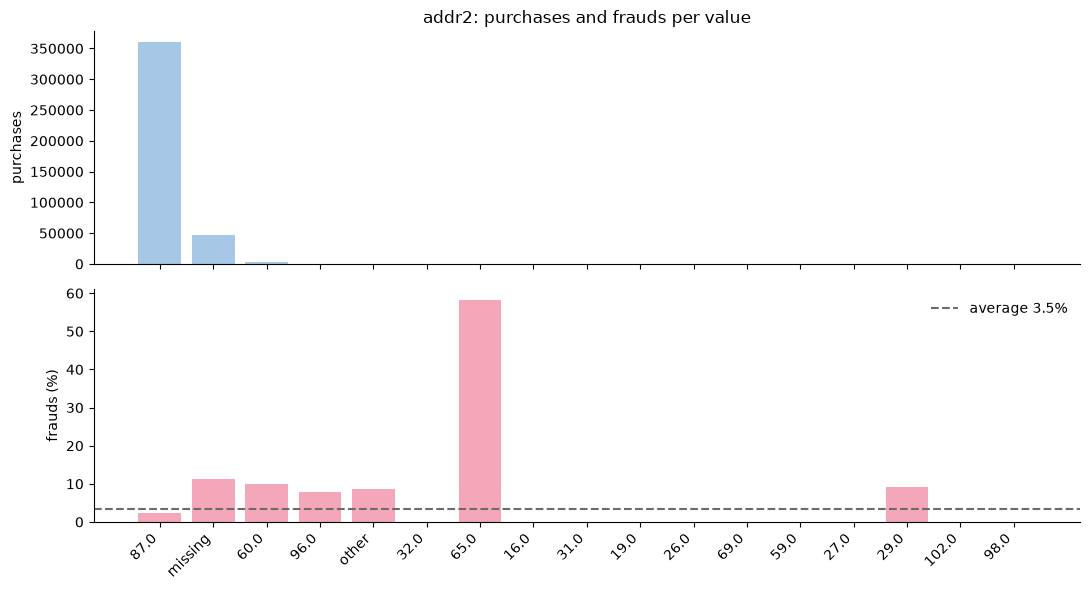

,purchases,fraud_pct
addr2,,
87.0,359809,2.438516
missing,47184,11.219905
60.0,2567,9.855863
96.0,516,7.751938
other,160,8.750000
32.0,77,0.000000
65.0,74,58.108108
16.0,47,0.000000
31.0,44,0.000000


In [17]:
category(train, "addr2")

**Finding:** One country (87) covers almost everything, at 2%. Missing: 11% (same rows as addr1). Value 65 has 58% fraud but on very few purchases: to watch, not to trust.

dist1: missing 61.9% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.44%


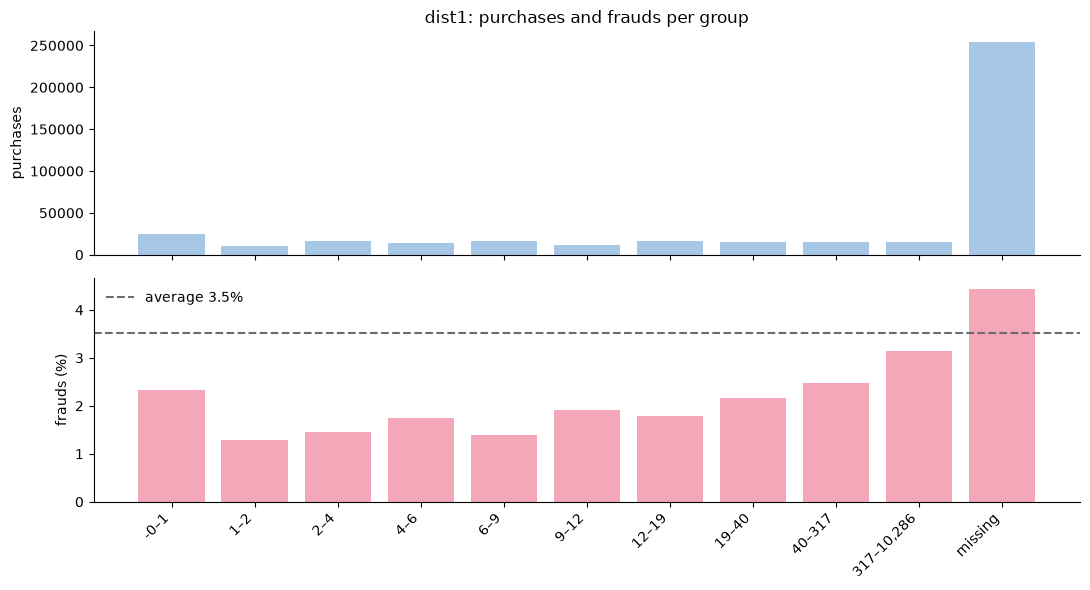

,purchases,fraud_pct
dist1,,
-0–1,24558,2.321036
1–2,10719,1.278104
2–4,16814,1.463066
4–6,14192,1.754510
6–9,16287,1.393750
9–12,11345,1.921551
12–19,15901,1.792340
19–40,15609,2.171824
40–317,15376,2.484391


In [18]:
numeric(train, "dist1")

**Finding:** Weak but ordered: the larger the distance, the more fraud (from 1.3% to 3.1%). Missing: 4.4%, a bit above the average.

dist2: missing 92.9% of the rows
  fraud rate WITH a value:    9.20%
  fraud rate WITHOUT a value: 3.08%


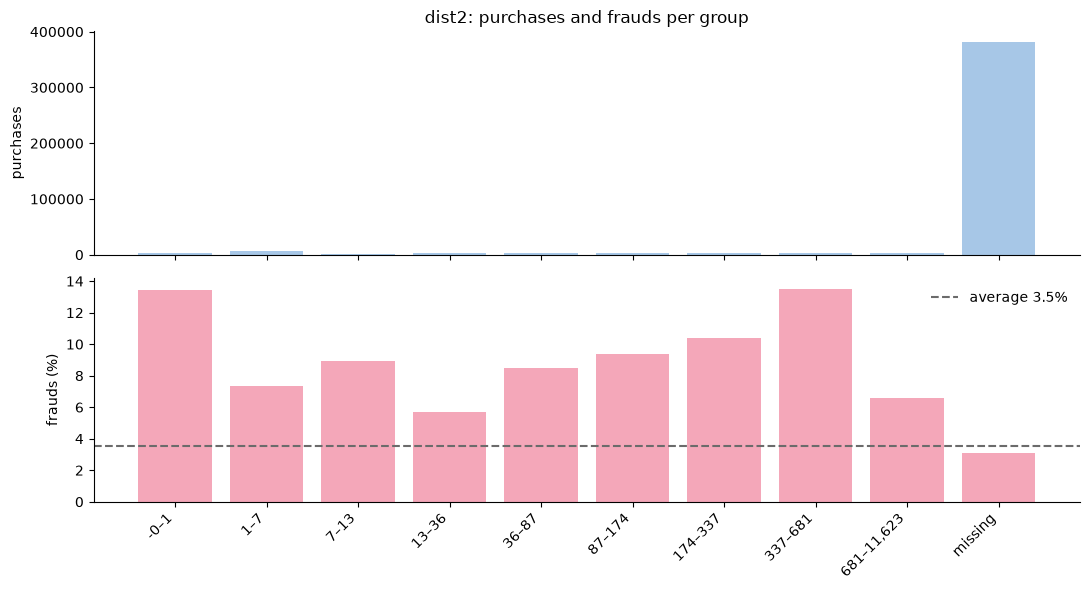

,purchases,fraud_pct
dist2,,
-0–1,3595,13.435327
1–7,6678,7.367475
7–13,1562,8.962868
13–36,2735,5.703839
36–87,2866,8.478716
87–174,2889,9.380408
174–337,2911,10.374442
337–681,2896,13.501381
"681–11,623",2904,6.611570


In [19]:
numeric(train, "dist2")

**Finding:** What matters is that it exists. It is present in only ~7% of purchases, and when present fraud is 6-13% whatever the distance; when missing, 3% → new feature: dist2 present yes/no.

## 5. Email domains

Type: **codes, many values**

P_emaildomain: missing 15.6% of the rows
  fraud rate WITH a value:    3.61%
  fraud rate WITHOUT a value: 3.00%


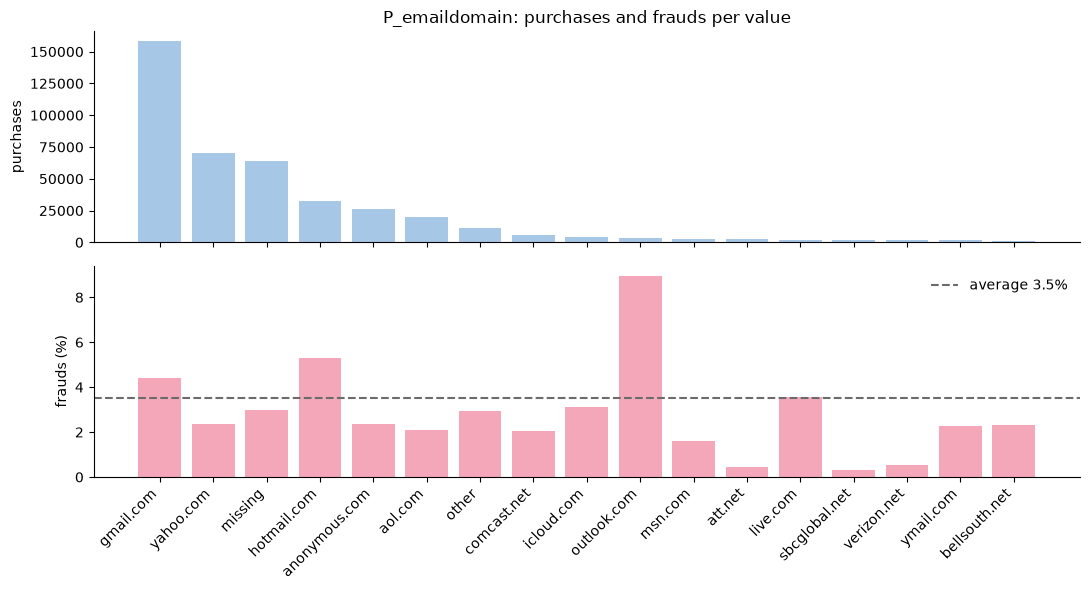

,purchases,fraud_pct
P_emaildomain,,
gmail.com,158056,4.400972
yahoo.com,69933,2.356541
missing,63889,3.002082
hotmail.com,32587,5.311934
anonymous.com,26589,2.365640
aol.com,19689,2.087460
other,11322,2.958841
comcast.net,5711,2.066188
icloud.com,4292,3.098788


In [20]:
category(train, "P_emaildomain")

**Finding:** Useful. Some domains are riskier: outlook.com 9% (few purchases), hotmail.com 5.3%, gmail.com 4.4% (on 158,000 purchases). Internet provider emails (att.net, sbcglobal.net, verizon.net) are very safe (under 0.5%).

R_emaildomain: missing 75.0% of the rows
  fraud rate WITH a value:    7.67%
  fraud rate WITHOUT a value: 2.13%


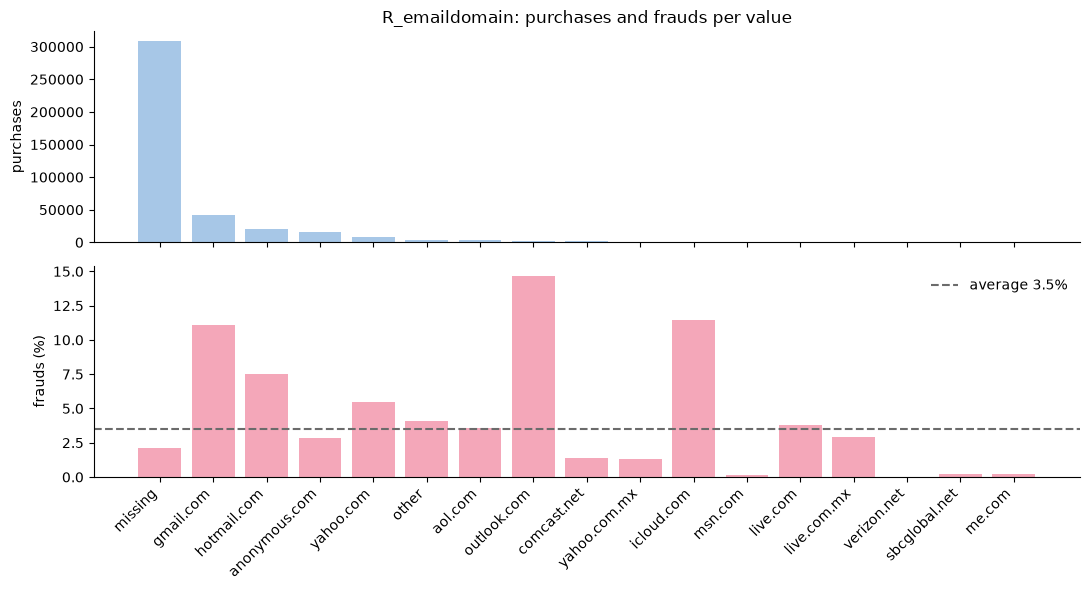

,purchases,fraud_pct
R_emaildomain,,
missing,308095,2.126617
gmail.com,42410,11.079934
hotmail.com,20370,7.540501
anonymous.com,15736,2.878749
yahoo.com,8250,5.503030
other,3997,4.053040
aol.com,3055,3.567921
outlook.com,1760,14.659091
comcast.net,1506,1.394422


In [21]:
category(train, "R_emaildomain")

**Finding:** What matters is that it exists: with a receiver email, fraud is much higher (gmail 11%, outlook 15%, icloud 11.5%); without it, 2%. Buying for someone else is a way for a thief to receive the goods → new feature: R_emaildomain present yes/no.

## 6. C1 – C14 (counts)

Type: **numbers**. First C1 alone, then all the C together: a table (one row per column) and the copies.

C1: missing 0.0% of the rows


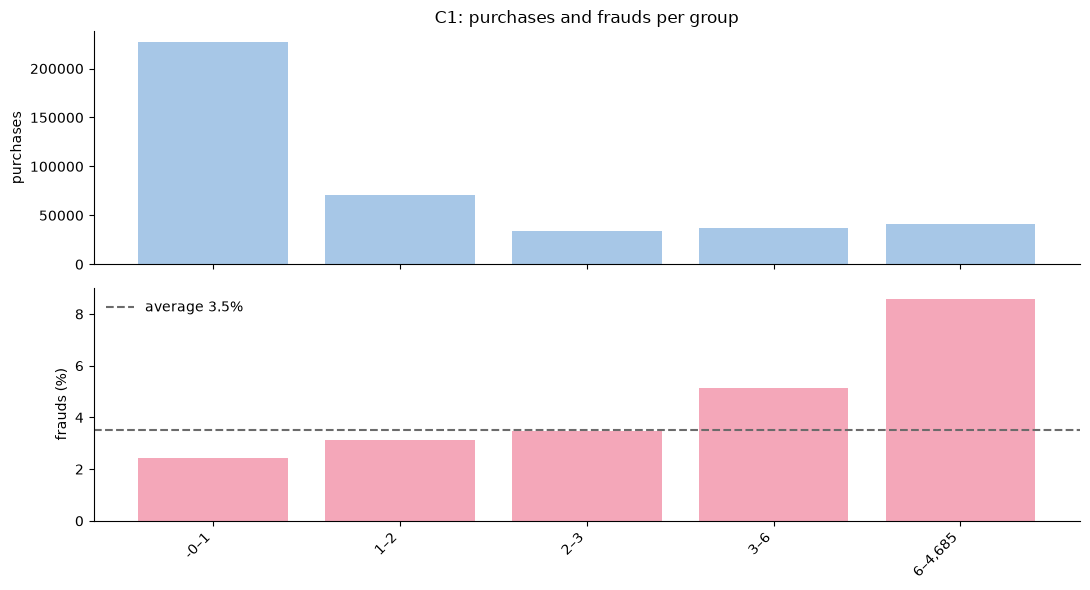

,purchases,fraud_pct
C1,,
-0–1,226679,2.449278
1–2,71100,3.144866
2–3,34508,3.462965
3–6,37374,5.145288
"6–4,685",40940,8.580850


In [22]:
numeric(train, "C1")

**Finding:** Strong and ordered: the higher the count (e.g. how many addresses are linked to the card), the more fraud, from 2.4% to 8.6%.

In [23]:
C = [f"C{i}" for i in range(1, 15)]
overview(train, C)

,missing %,fraud % if missing,lowest group %,highest group %,strength
column,,,,,
C1,0.0,None,2.4,8.6,2.4
C2,0.0,None,2.3,8.8,2.5
C3,0.0,None,3.5,3.5,1.0
C4,0.0,None,2.7,22.0,6.3
C5,0.0,None,1.0,4.0,1.1
C6,0.0,None,2.8,6.5,1.9
C7,0.0,None,2.9,27.7,7.9
C8,0.0,None,2.6,17.6,5.0
C9,0.0,None,2.1,4.0,1.1


**Finding:** _write here._ Which C are strong (strength over 2)?

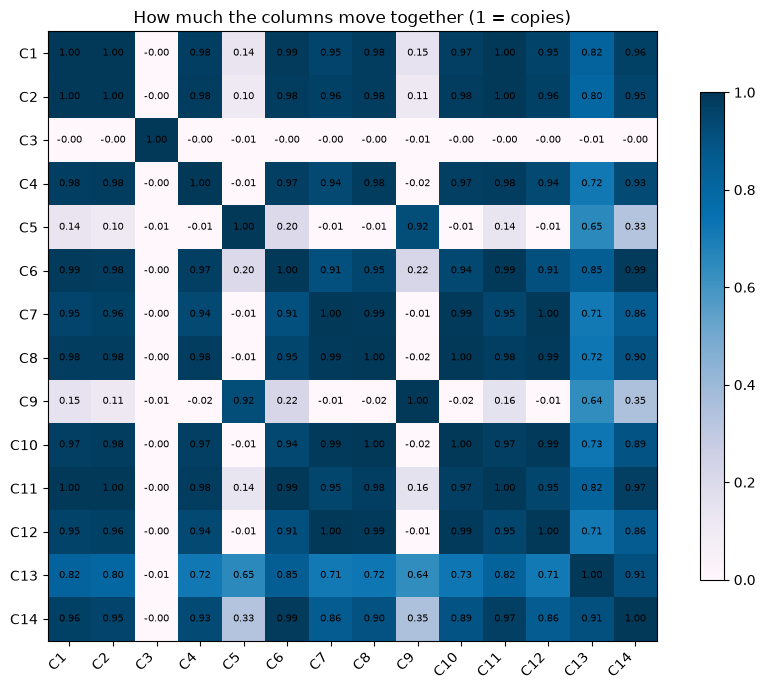

almost copies: [('C1', 'C2', 1.0), ('C1', 'C4', 0.98), ('C1', 'C6', 0.99), ('C1', 'C7', 0.95), ('C1', 'C8', 0.98), ('C1', 'C10', 0.97), ('C1', 'C11', 1.0), ('C1', 'C12', 0.95), ('C1', 'C14', 0.96), ('C2', 'C4', 0.98), ('C2', 'C6', 0.98), ('C2', 'C7', 0.96), ('C2', 'C8', 0.98), ('C2', 'C10', 0.98), ('C2', 'C11', 1.0), ('C2', 'C12', 0.96), ('C2', 'C14', 0.95), ('C4', 'C6', 0.97), ('C4', 'C8', 0.98), ('C4', 'C10', 0.97), ('C4', 'C11', 0.98), ('C6', 'C11', 0.99), ('C6', 'C14', 0.99), ('C7', 'C8', 0.99), ('C7', 'C10', 0.99), ('C7', 'C12', 1.0), ('C8', 'C10', 1.0), ('C8', 'C11', 0.98), ('C8', 'C12', 0.99), ('C10', 'C11', 0.97), ('C10', 'C12', 0.99), ('C11', 'C14', 0.97)]


In [24]:
copies(train, C)

**Finding:** Ten C are almost copies of each other (C1, C2, C4, C6, C7, C8, C10, C11, C12, C14: correlation 0.95–1.0, linked in one chain). C3, C5, C9 and C13 are not copies of any other column.


In [25]:
C_keep = keep_one(train, C)

copies ['C1', 'C2', 'C4', 'C6', 'C7', 'C8', 'C10', 'C11', 'C12', 'C14'] -> keep C7
14 columns -> 5 kept: ['C7', 'C3', 'C5', 'C9', 'C13']


**Finding:** From 14 C to 5: C7 (for the group of ten copies), C3, C5, C9, C13.

## 7. D1 – D15 (days passed)

Type: **numbers**. Same method as the C.

D1: missing 0.1% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 0.37%


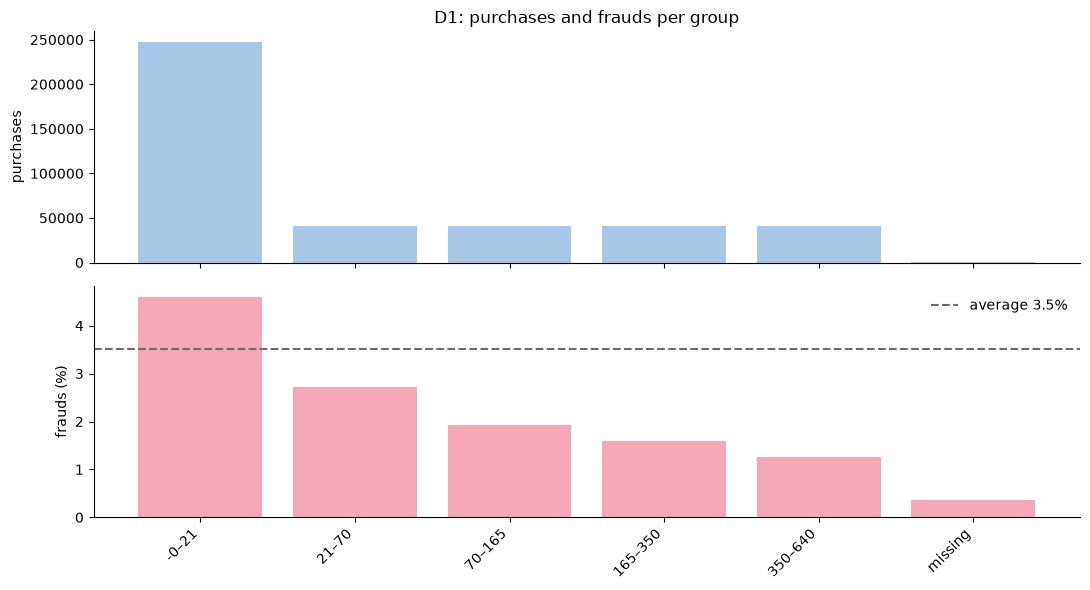

,purchases,fraud_pct
D1,,
-0–21,246990,4.595733
21–70,40942,2.720922
70–165,40458,1.935340
165–350,40974,1.586372
350–640,40964,1.269407
missing,273,0.366300


In [26]:
numeric(train, "D1")

**Finding:** Strong and ordered: cards seen recently are riskier (4.6% for 0-21 days vs 1.3% for more than one year). But an old card can be stolen too: D1 alone is not enough, it must be combined with "is this purchase different from the card's usual behaviour?".

In [27]:
D = [f"D{i}" for i in range(1, 16)]
overview(train, D)

,missing %,fraud % if missing,lowest group %,highest group %,strength
column,,,,,
D1,0.1,0.4,1.3,4.6,1.3
D2,50.0,4.4,0.9,8.3,2.4
D3,47.2,4.1,0.9,6.2,1.8
D4,29.6,3.6,1.5,8.1,2.3
D5,54.2,3.1,0.9,9.1,2.6
D6,87.3,2.5,4.2,22.2,6.3
D7,93.5,2.7,2.7,20.2,5.8
D8,86.4,2.5,2.2,19.9,5.7
D9,86.4,2.5,6.3,17.6,5.0


**Finding:** _write here._ Which D are strong? Which are almost always missing?

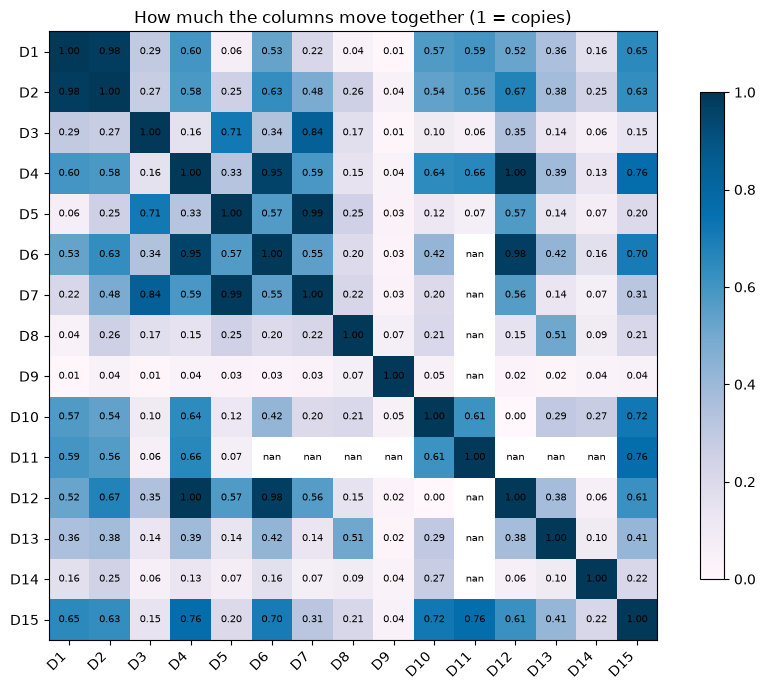

almost copies: [('D1', 'D2', 0.98), ('D4', 'D6', 0.95), ('D4', 'D12', 1.0), ('D5', 'D7', 0.99), ('D6', 'D12', 0.98)]


In [28]:
copies(train, D)

**Finding:** Three groups of copies: {D1, D2}, {D4, D6, D12}, {D5, D7}. The other D are not copies of any other column.

In [29]:
D_keep = keep_one(train, D)

copies ['D1', 'D2'] -> keep D1
copies ['D4', 'D6', 'D12'] -> keep D4
copies ['D5', 'D7'] -> keep D5
15 columns -> 11 kept: ['D1', 'D3', 'D4', 'D5', 'D8', 'D9', 'D10', 'D11', 'D13', 'D14', 'D15']


**Finding:** From 15 D to 11: D1 (for D1/D2), D4 (for D4/D6/D12), D5 (for D5/D7), and D3, D8, D9, D10, D11, D13, D14, D15.

## 8. M1 – M9 (matches, true / false)

Type: **codes, few values** (T = true, F = false; M4 has M0/M1/M2).

M1: missing 54.0% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.79%


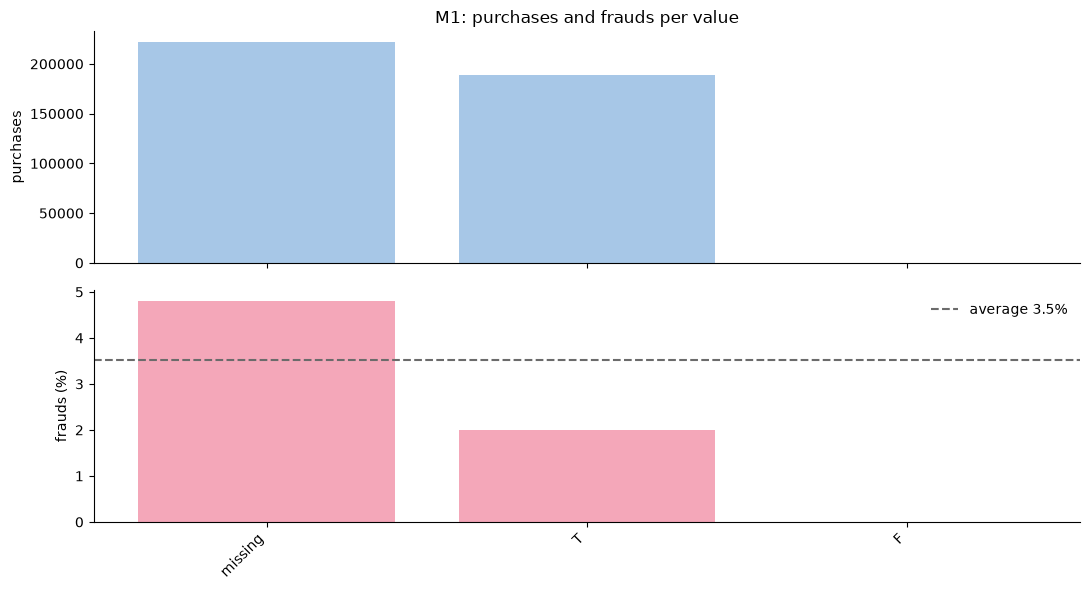

M2: missing 54.0% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.79%


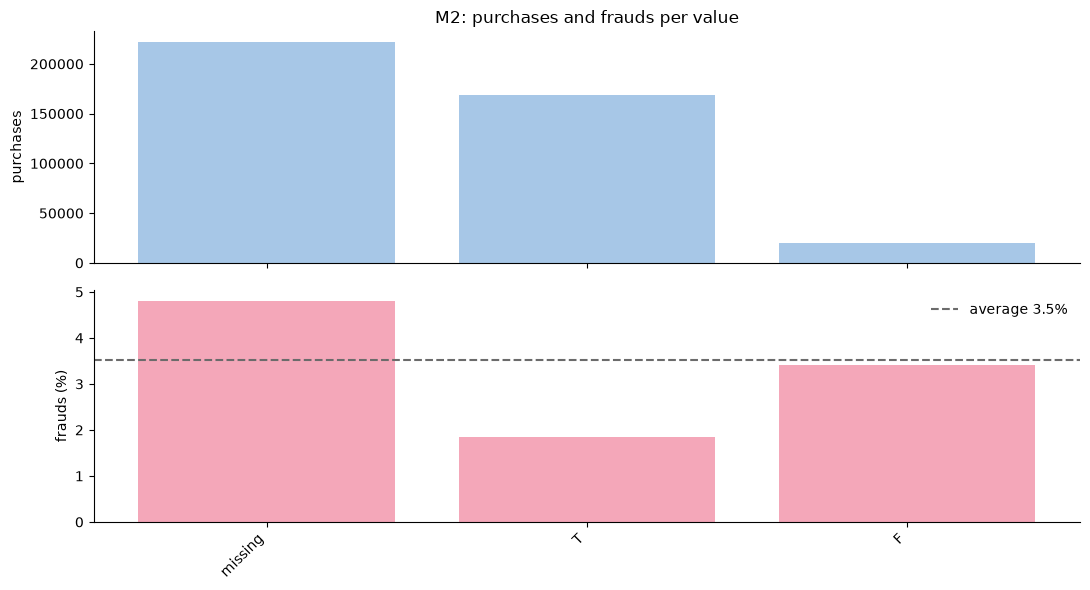

M3: missing 54.0% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.79%


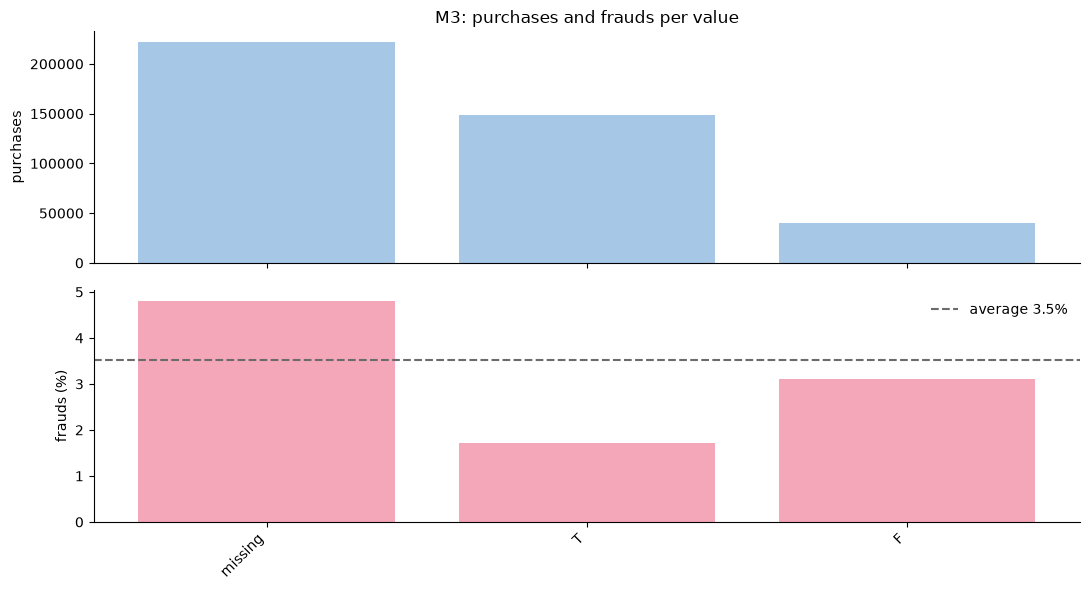

M4: missing 48.5% of the rows
  fraud rate WITH a value:    5.04%
  fraud rate WITHOUT a value: 1.89%


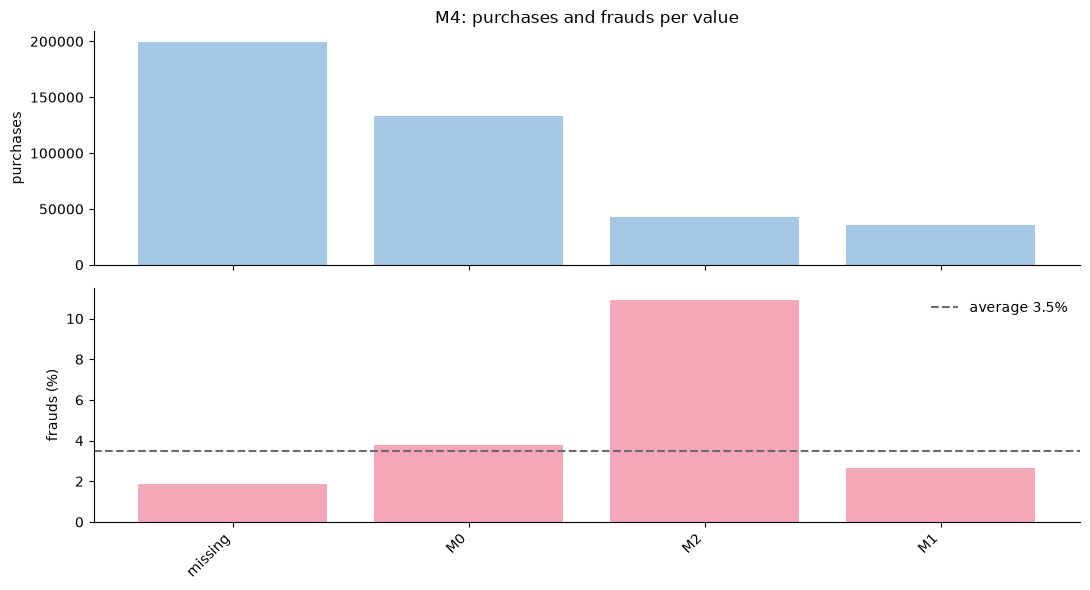

M5: missing 60.5% of the rows
  fraud rate WITH a value:    3.25%
  fraud rate WITHOUT a value: 3.69%


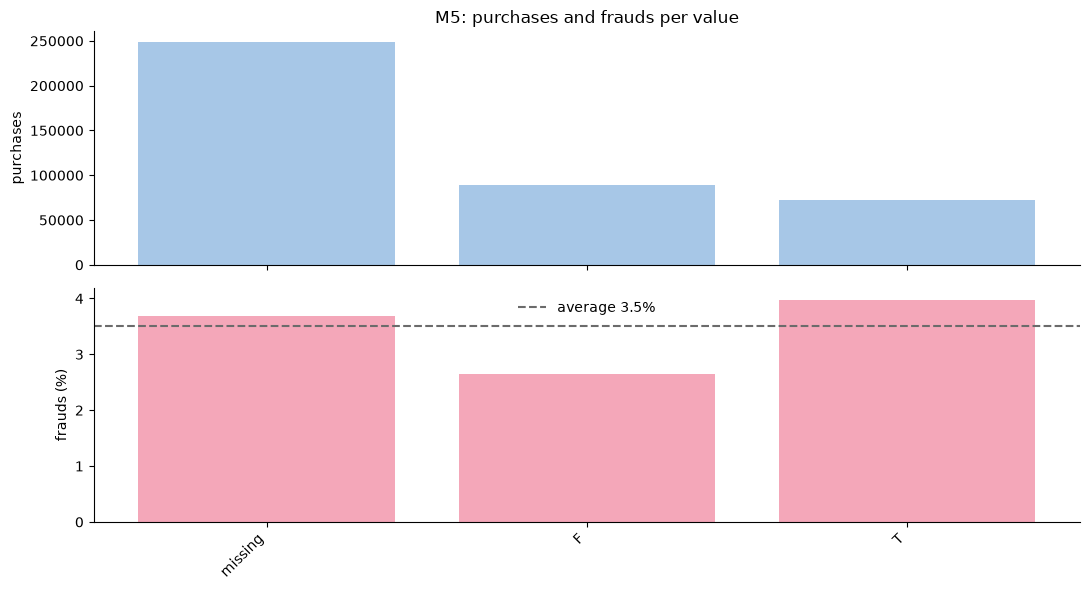

M6: missing 31.2% of the rows
  fraud rate WITH a value:    2.10%
  fraud rate WITHOUT a value: 6.63%


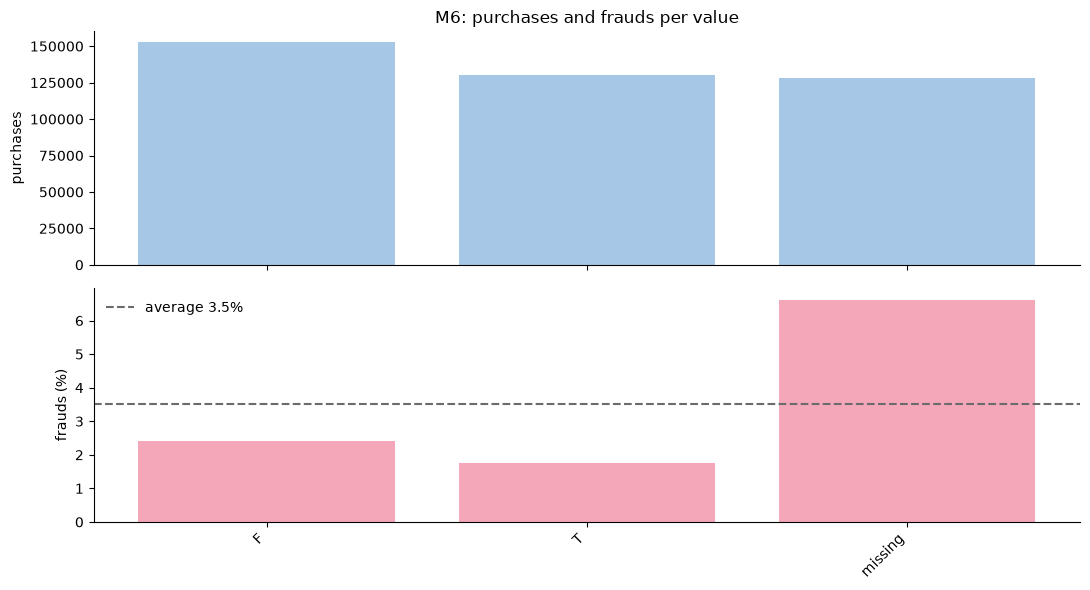

M7: missing 67.1% of the rows
  fraud rate WITH a value:    1.97%
  fraud rate WITHOUT a value: 4.27%


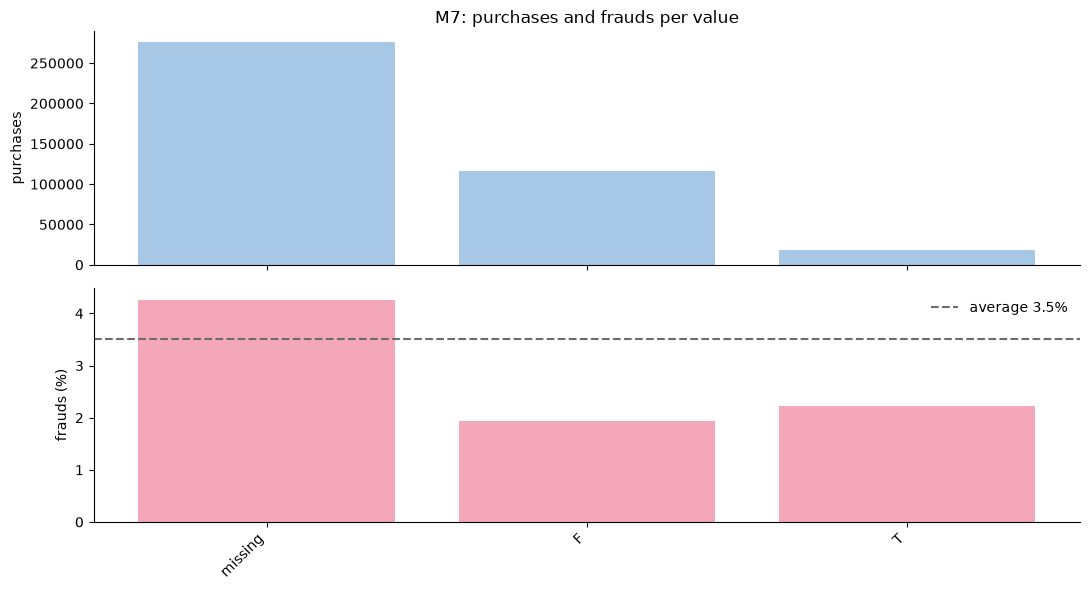

M8: missing 67.1% of the rows
  fraud rate WITH a value:    1.97%
  fraud rate WITHOUT a value: 4.27%


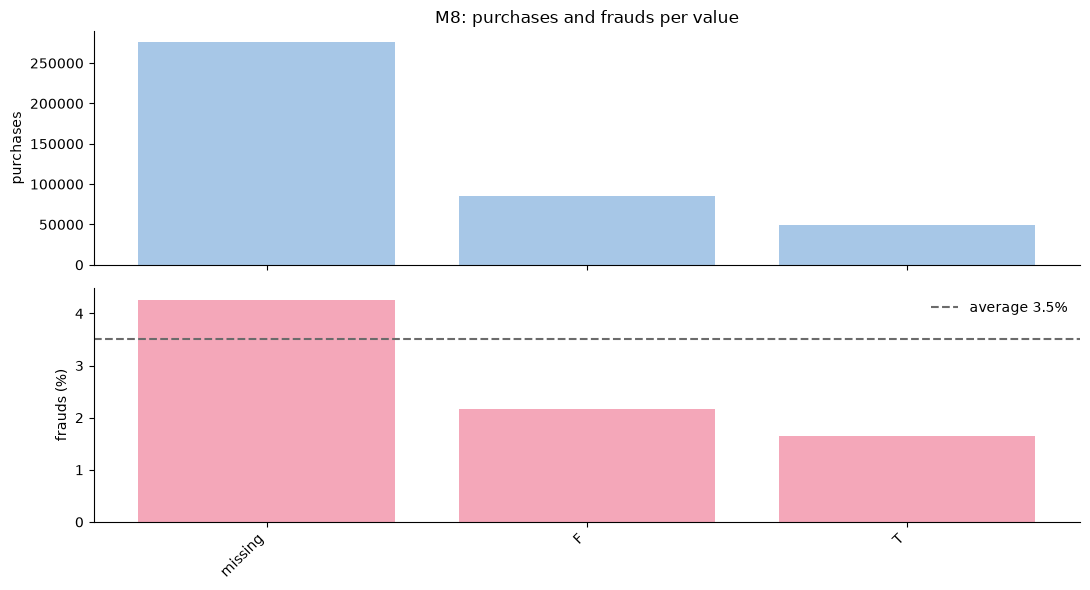

M9: missing 67.1% of the rows
  fraud rate WITH a value:    1.97%
  fraud rate WITHOUT a value: 4.27%


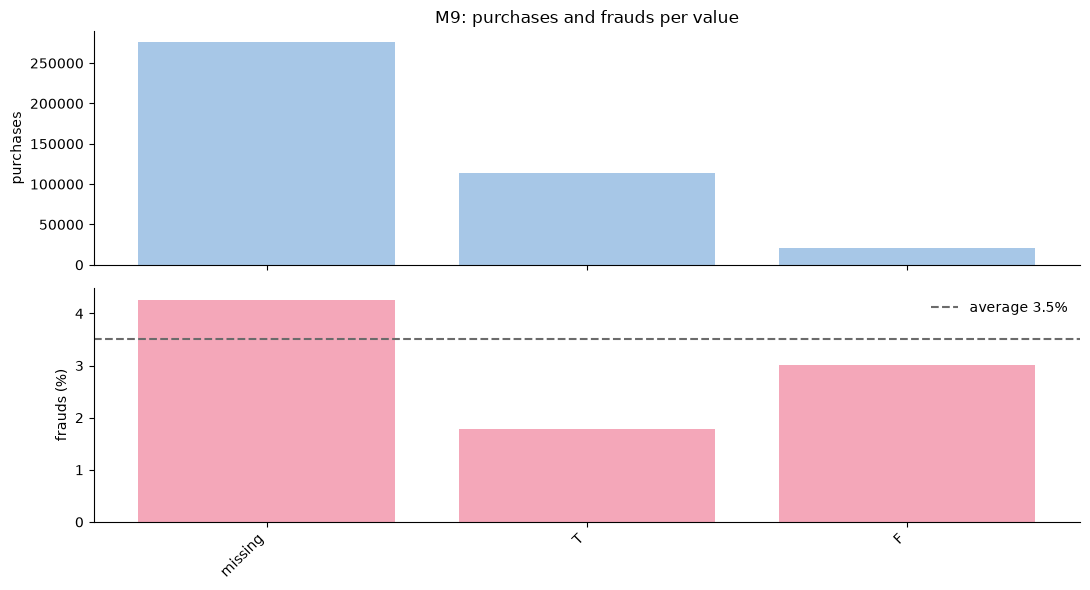

In [30]:
for col in [f"M{i}" for i in range(1, 10)]:
    category(train, col)

**Finding:** _write here._

## 9. V1 – V339

339 columns. Two steps:
1. group the V by **missing pattern**: columns that are empty on exactly the same rows form a block;
2. inside each block, the same method as the C: `overview` and `copies`, keep one column per group of copies.

### Step 1: blocks of V that are missing on the same rows

In [31]:
V = [f"V{i}" for i in range(1, 340)]
missing_count = train[V].isna().sum()                     # how many empty rows each V has
blocks = [list(cols) for cols in missing_count.groupby(missing_count).groups.values()]

pd.DataFrame({
    "block": range(len(blocks)),
    "columns": [len(b) for b in blocks],
    "missing %": [round(100 * missing_count[b[0]] / len(train), 1) for b in blocks],
    "from": [b[0] for b in blocks],
    "to": [b[-1] for b in blocks],
}).set_index("block")

,columns,missing %,from,to
block,,,,
0,43,0.0,V95,V137
1,32,0.0,V279,V321
2,11,0.1,V281,V315
3,23,14.9,V12,V34
4,22,15.2,V53,V74
5,20,16.6,V75,V94
6,18,29.6,V35,V52
7,11,54.8,V1,V11
8,16,73.8,V220,V272


**Finding:** _write here: how many blocks, how big, how empty._

### Step 2: inside each block, keep one column per group of copies

For C and D the limit is 0.95 ("almost identical"). For the V it is **0.75** ("very similar"): with 0.95 the V went only from 339 to ~290, because many V are variants of the same count built by Vesta, very similar but not identical. The V are anonymous, so we lose nothing by keeping one per group of similar columns.

In [32]:
V_LIMIT = 0.75      # V: 'very similar' is enough (they are anonymous, we don't explain them one by one)
V_keep = []
for n, cols in enumerate(blocks):
    print(f"\n--- block {n} ({len(cols)} columns) ---")
    V_keep += keep_one(train, cols, limit=V_LIMIT)
print(f"\nV: {len(V)} columns -> {len(V_keep)} kept")


--- block 0 (43 columns) ---
copies ['V95', 'V101'] -> keep V95
copies ['V96', 'V97', 'V99', 'V100', 'V102', 'V103'] -> keep V97
copies ['V104', 'V105', 'V106'] -> keep V104
copies ['V108', 'V109', 'V110'] -> keep V108
copies ['V111', 'V112', 'V113'] -> keep V111
copies ['V114', 'V116'] -> keep V114
copies ['V117', 'V118', 'V119'] -> keep V117
copies ['V120', 'V122'] -> keep V120
copies ['V123', 'V124', 'V125'] -> keep V123
copies ['V126', 'V127', 'V128', 'V132', 'V133', 'V134'] -> keep V126
copies ['V129', 'V130', 'V131'] -> keep V131
copies ['V135', 'V136', 'V137'] -> keep V135
43 columns -> 16 kept: ['V95', 'V97', 'V98', 'V104', 'V107', 'V108', 'V111', 'V114', 'V115', 'V117', 'V120', 'V121', 'V123', 'V126', 'V131', 'V135']

--- block 1 (32 columns) ---
copies ['V279', 'V280', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V306', 'V307', 'V308', 'V317', 'V318'] -> keep V292
copies ['V285', 'V287'] -> keep V287
copies ['V297', 'V299'] -> keep V297
copies ['V302', 'V303', 'V304'] ->

### Step 3: which of the kept V are strong

In [33]:
overview(train, V_keep).sort_values("strength", ascending=False).head(20)

,missing %,fraud % if missing,lowest group %,highest group %,strength
column,,,,,
V153,84.2,3.4,3.4,77.6,22.1
V194,74.2,2.2,6.8,69.9,19.9
V257,75.6,2.3,5.1,66.1,18.8
V250,73.8,2.2,6.7,56.7,16.1
V111,0.0,NaN,3.4,51.6,14.7
V188,74.2,2.2,5.5,51.5,14.7
V255,73.8,2.2,6.6,50.7,14.4
V186,74.2,2.2,5.4,44.1,12.6
V117,0.0,NaN,3.5,40.6,11.6


**Finding:** _write here: how many V are left, and which are the strongest._

## 10. Identity table (device, browser)

To be joined with `train_transaction` on `TransactionID`. Later.

## 11. Selected features

What goes to the next step (feature engineering and model). Kept:
- the readable features found useful above;
- from C, D and V: one column per group of copies (`C_keep`, `D_keep`, `V_keep`);
- all the M (few columns, to be confirmed by their charts).

New features to **build** in the next step (they are not columns yet): `addr1_missing`, `dist2_present`,
`R_emaildomain_present`, amount compared to the card's usual amount. `card1` is kept to rebuild the card /
customer. `month` and `day` are not features: they are only used to split the data in time.

In [34]:
import json

READABLE = ["TransactionAmt", "ProductCD", "hour", "weekday",
            "card1", "card2", "card3", "card4", "card5", "card6",
            "addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain"]
M = [f"M{i}" for i in range(1, 10)]

selected = READABLE + C_keep + D_keep + M + V_keep
print(f"{len(selected)} features kept, out of {df.shape[1]} columns")
print(f"  readable {len(READABLE)} | C {len(C_keep)} | D {len(D_keep)} | M {len(M)} | V {len(V_keep)}")

with open("eda_selected_features.json", "w") as f:        # read by the next notebook
    json.dump(selected, f, indent=1)

149 features kept, out of 398 columns
  readable 16 | C 5 | D 11 | M 9 | V 108


## Statistics concepts used in this analysis

| concept | where |
|---|---|
| **Base rate and class imbalance**: only 3.5% of purchases are frauds, so accuracy is useless | the first numbers |
| **Conditional probability**: fraud rate *given* a group, P(fraud \| group) | every pink bar |
| **Lift (relative risk)**: group rate ÷ average rate, our "strength" | ProductCD, card3, C, D |
| **Sample size and noise**: a % on a small group can be chance | card4 Discover, addr2 = 65 |
| **Quantile binning**: groups with the same number of purchases (`qcut`) | every number |
| **Non-linear relationships**: correlation misses mountains and U-shapes | hour, amount |
| **Variable types**: numbers vs codes (nominal categories), high cardinality | card1, addr1 |
| **Informative missing values** (not missing at random) | addr1, dist2, R_emaildomain |
| **Multicollinearity**: columns that are almost copies, one kept per group | C, D, V |
| **Pearson correlation is sensitive to extreme values** | C (values up to thousands) |
| **Non-stationarity / drift**: the fraud rate changes over time | per month |
| **Data leakage and time split**: decisions only on months 0-3 | the whole analysis |

## Summary

| feature | useful? | what we do with it |
|---|---|---|
| hour | strong (3x at night) | feature |
| TransactionAmt | weak alone | new feature: amount / card's usual amount |
| ProductCD | strong | category; rule candidate (ProductCD = C) |
| card4 | weak | category (only Discover stands out) |
| card6 | useful | category |
| card1 | too many values | used to identify the card / customer |
| card2 | useful, weaker | category + missing flag |
| card3 | strong | category (185) |
| card5 | useful | category |
| addr1 / addr2 | the missing value is strong | missing flag |
| dist1 | weak | number |
| dist2 | presence is strong | present flag |
| P_emaildomain | useful | category (clean similar domains) |
| R_emaildomain | presence is strong | present flag + category |
| C1 | strong | number |
| D1 | strong | number |
| C2 – C14 | | |
| D2 – D15 | | |
| M1 – M9 | | |